# 02 — PDE10A EDA & Baseline Models

**Dataset**: 1162 PDE10A inhibitors with pIC50 values  
**Focus**: EDA (pIC50 distribution, binding modes, temporal coverage, split strategies); then baseline ML models across all 7 pre-defined split strategies (temporal 2011–2013, 3 chemotype-based, random).  
**Reuses**: `src.splitting`, `src.features`, `src.models`, `src.plotting`

In [23]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.splitting import get_split, list_split_cols, SPLIT_COLS
from src.eda import smiles_validity_report, missing_value_report, max_corr_report
from src.features import morgan_fingerprints, rdkit_descriptors
from src.models import get_baseline_models, evaluate_model
from src.plotting import pred_vs_actual_grid

DATA_PATH = '../data/raw/10822_2022_478_MOESM2_ESM.csv'
SMILES_COL = 'SMILES'
TARGET_COL = 'pic50'
SEED = 42

## Part 1 — Exploratory Data Analysis

### 1.1 Load & Inspect

In [24]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
display(df.head(3))
display(df.dtypes)


Shape: (1162, 14)

Columns: ['compound_id', 'SMILES', 'binding_mode_class', 'pic50', 'pic50_date', 'DATESOLVED', 'docking_folder', 'aminohetaryl_c1_amide_split', 'aryl_c1_amide_c2_hetaryl_split', 'temporal_2012_split', 'c1_hetaryl_alkyl_c2_hetaryl_split', 'temporal_2013_split', 'temporal_2011_split', 'random_split']


,compound_id,SMILES,binding_mode_class,pic50,pic50_date,DATESOLVED,docking_folder,aminohetaryl_c1_amide_split,aryl_c1_amide_c2_hetaryl_split,temporal_2012_split,c1_hetaryl_alkyl_c2_hetaryl_split,temporal_2013_split,temporal_2011_split,random_split
0,0,Cn1ncc(C(=O)N2CCC2)c1C(=O)NCCc1nc(-c2cccc(F)c2...,aryl_c1_amide_c2_hetaryl,9.181370,14-Nov-2011,08-Nov-11,5sf8_0,train,test,val,val,train,test,val
1,1,CCN(C)C(=O)c1cnn(C)c1C(=O)Nc1ccn2cc(-c3cccc(OC...,aryl_c1_amide_c2_hetaryl,8.217886,11-Apr-2011,21-Jul-10,5sfr_1,train,test,train,val,train,test,train
2,2,Cn1cncc1Cn1nc(-c2ccccn2)cc1NC(=O)c1nc(C2CC2)cc...,aminohetaryl_c1_amide,8.819874,11-Jan-2010,15-Jun-09,5sf4_2,test,train,train,train,train,train,train


compound_id                            int64
SMILES                                object
binding_mode_class                    object
pic50                                float64
pic50_date                            object
DATESOLVED                            object
docking_folder                        object
aminohetaryl_c1_amide_split           object
aryl_c1_amide_c2_hetaryl_split        object
temporal_2012_split                   object
c1_hetaryl_alkyl_c2_hetaryl_split     object
temporal_2013_split                   object
temporal_2011_split                   object
random_split                          object
dtype: object

### 1.2 SMILES Validity

In [25]:
report = smiles_validity_report(df, SMILES_COL)
print(f"Valid SMILES:   {report['valid_count']}")
print(f"Invalid SMILES: {report['invalid_count']}")
if report['invalid_indices']:
    print(f"Invalid at indices: {report['invalid_indices']}")


Valid SMILES:   1162
Invalid SMILES: 0


### 1.3 Duplicate Check

In [26]:
from rdkit import Chem

assert report['invalid_count'] == 0, f"Fix {report['invalid_count']} invalid SMILES before canonicalising"

def to_canonical(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol is not None else None

n_raw_dupes = df[SMILES_COL].duplicated().sum()
canonical = df[SMILES_COL].apply(to_canonical)
n_canon_dupes = canonical.duplicated().sum()

print(f'Raw SMILES duplicates:       {n_raw_dupes}')
print(f'Canonical SMILES duplicates: {n_canon_dupes}')

Raw SMILES duplicates:       0
Canonical SMILES duplicates: 0


### 1.3a Stereoisomer Check

Compounds sharing the same flat (stereo-stripped) scaffold but differing in stereochemistry. These have identical fingerprints under ECFP4 with `useChirality=False` (our default), so the model sees the same input for different pIC50 values — a form of intrinsic label noise.

In [27]:
# Stereoisomer detection: strip stereo from canonical SMILES, group by flat structure
def to_flat(smi):
    mol = Chem.MolFromSmiles(str(smi)) if not pd.isna(smi) else None
    return Chem.MolToSmiles(mol, isomericSmiles=False) if mol is not None else None

flat_smiles = df[SMILES_COL].apply(to_flat)
stereo_groups = flat_smiles.groupby(flat_smiles).filter(lambda g: len(g) > 1)
n_stereo_pairs = flat_smiles.isin(stereo_groups).sum()
stereo_flat = flat_smiles[flat_smiles.isin(stereo_groups)].unique()

print(f'Compounds involved in stereoisomer groups: {n_stereo_pairs}')
print(f'Distinct flat scaffolds with >1 stereoisomer: {len(stereo_flat)}')

if n_stereo_pairs > 0:
    for flat in stereo_flat:
        idx = df[flat_smiles == flat].index
        group = df.loc[idx, ['compound_id', SMILES_COL, TARGET_COL, 'binding_mode_class']]
        print(f'\nFlat SMILES: {flat[:80]}...' if len(flat) > 80 else f'\nFlat SMILES: {flat}')
        display(group.reset_index(drop=True))


Compounds involved in stereoisomer groups: 16
Distinct flat scaffolds with >1 stereoisomer: 8

Flat SMILES: Cn1ncc(C(=O)N2CCOCC2)c1C(=O)NC1CCn2cc(-c3ccc(F)cc3)nc2C1


,compound_id,SMILES,pic50,binding_mode_class
0,346,Cn1ncc(C(=O)N2CCOCC2)c1C(=O)N[C@@H]1CCn2cc(-c3...,5.362921,aryl_c1_amide_c2_hetaryl
1,938,Cn1ncc(C(=O)N2CCOCC2)c1C(=O)N[C@H]1CCn2cc(-c3c...,6.204815,aryl_c1_amide_c2_hetaryl



Flat SMILES: Cn1ncc(C(=O)N2CCOCC2)c1C(=O)NC1CCn2cc(-c3ccccc3Cl)nc2C1


,compound_id,SMILES,pic50,binding_mode_class
0,457,Cn1ncc(C(=O)N2CCOCC2)c1C(=O)N[C@@H]1CCn2cc(-c3...,5.617731,aryl_c1_amide_c2_hetaryl
1,1009,Cn1ncc(C(=O)N2CCOCC2)c1C(=O)N[C@H]1CCn2cc(-c3c...,6.360514,aryl_c1_amide_c2_hetaryl



Flat SMILES: Cc1ncc(C)n2nc(C=Cc3nc(N4CCC(C)C4)nn3C)nc12


...

,compound_id,SMILES,pic50,binding_mode_class
0,893,Cn1ncc(NC(=O)c2nc(C3CC3)cnc2Nc2cncnc2)c1C(=O)N...,8.453828,aminohetaryl_c1_amide
1,916,Cn1ncc(NC(=O)c2nc(C3CC3)cnc2Nc2cncnc2)c1C(=O)N...,8.163296,aminohetaryl_c1_amide



Flat SMILES: CNC(=O)C1CCCC1NC(=O)c1nc(C2CC2)cnc1Nc1cncnc1


,compound_id,SMILES,pic50,binding_mode_class
0,971,CNC(=O)[C@@H]1CCC[C@H]1NC(=O)c1nc(C2CC2)cnc1Nc...,5.944388,aminohetaryl_c1_amide
1,1000,CNC(=O)[C@H]1CCC[C@@H]1NC(=O)c1nc(C2CC2)cnc1Nc...,6.157286,aminohetaryl_c1_amide



Flat SMILES: CC(=Cc1nc2c(C)ncc(C)n2n1)c1nc(Br)nn1C


,compound_id,SMILES,pic50,binding_mode_class
0,1125,C/C(=C\c1nc2c(C)ncc(C)n2n1)c1nc(Br)nn1C,5.316821,c1_hetaryl_alkyl_c2_hetaryl
1,1134,C/C(=C/c1nc2c(C)ncc(C)n2n1)c1nc(Br)nn1C,5.645752,c1_hetaryl_alkyl_c2_hetaryl


### 1.4 pIC50 Distribution

Count:    1162
Mean:     7.288
Std:      1.167
Min/Max:  4.760 / 10.101
Skewness: -0.101
Kurtosis: -0.775


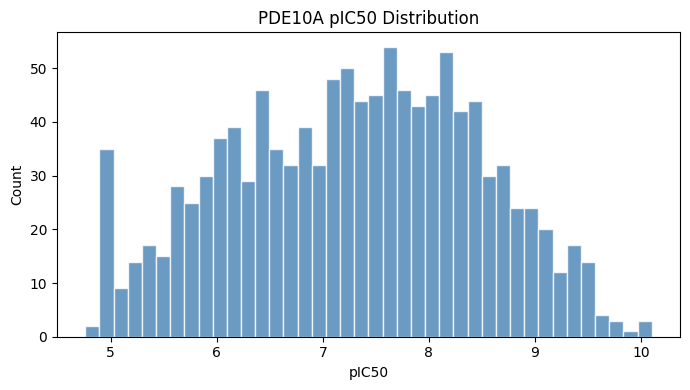

In [28]:
from scipy.stats import skew, kurtosis

pic50 = df[TARGET_COL].dropna()
print(f'Count:    {len(pic50)}')
print(f'Mean:     {pic50.mean():.3f}')
print(f'Std:      {pic50.std():.3f}')
print(f'Min/Max:  {pic50.min():.3f} / {pic50.max():.3f}')
print(f'Skewness: {skew(pic50):.3f}')
print(f'Kurtosis: {kurtosis(pic50):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pic50, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('pIC50')
ax.set_ylabel('Count')
ax.set_title('PDE10A pIC50 Distribution')
plt.tight_layout()
plt.show()


### 1.4a Spike Investigation — pIC50 ≈ 5

Visually, ~35 compounds cluster near pIC50 ≈ 5 with a gap before the main distribution resumes at ~5.5. We check: are values truly piled at a single cutoff, which binding modes/splits they belong to, and when they were measured.

In [29]:
# Value counts in spike region to show the pile-up vs scattered values
spike_df = df[df[TARGET_COL] < 5.5]
print(f'\npIC50 value counts in spike region (< 5.5), rounded to 2 dp:')
print(spike_df[TARGET_COL].round(2).value_counts().sort_index().to_string())

# How the 32 compounds are partitioned across each split strategy
exact_5 = df[df[TARGET_COL] == 5.00]
split_summary = pd.DataFrame({
    col.replace('_split', ''): exact_5[col].value_counts()
    for col in SPLIT_COLS
}).T.fillna(0).astype(int)

print('\nPartition assignment for pIC50 == 5.00 compounds:')
display(split_summary)


pIC50 value counts in spike region (< 5.5), rounded to 2 dp:
pic50
4.76     1
4.79     1
4.93     1
5.00    32
5.01     1
5.03     3
5.05     1
5.08     2
5.09     1
5.10     1
5.11     1
5.12     1
5.18     2
5.19     1
5.21     6
5.23     1
5.24     2
5.25     1
5.26     1
5.30     1
5.31     1
5.32     3
5.33     2
5.34     1
5.35     1
5.36     3
5.37     1
5.38     2
5.41     2
5.43     1
5.46     2
5.48     2
5.50     1

Partition assignment for pIC50 == 5.00 compounds:


,test,train,val
aminohetaryl_c1_amide,11,21,0
aryl_c1_amide_c2_hetaryl,18,14,0
temporal_2012,2,28,2
c1_hetaryl_alkyl_c2_hetaryl,3,25,4
temporal_2013,0,32,0
temporal_2011,4,24,2
random,8,19,5


### 1.4b Maximum Possible Correlation

Upper bound on Pearson r achievable for pIC50 (Brown, Muchmore & Hajduk noise model).  
Note: PDE10A has no missing target values, so this uses the full 1162-compound dataset.

In [30]:
mc_report = max_corr_report(df, [TARGET_COL])
mc_report.index = ['pIC50']
print('Maximum possible R² — pIC50 at 2x, 3x, 5x, 10x noise (Brown, Muchmore & Hajduk):')
display(mc_report.round(3))

Maximum possible R² — pIC50 at 2x, 3x, 5x, 10x noise (Brown, Muchmore & Hajduk):


,n,2-Fold,3-Fold,5-Fold,10-Fold
pIC50,1162,0.938,0.857,0.736,0.578


### 1.5 Outlier Detection

Flag compounds with `pic50` more than 3σ from the mean.  
**Policy**: flag only — no rows removed.  
Note: IQR rule not used here because `pic50` is approximately normally distributed (low skewness); 3σ is the more appropriate criterion for near-normal data.

In [31]:
pic50_vals = df[TARGET_COL]
mu, sigma = pic50_vals.mean(), pic50_vals.std()
mask = (pic50_vals - mu).abs() > 2.5 * sigma

df['outlier_pic50'] = mask

n_outliers = int(mask.sum())
print(f'2.5σ outlier count for pic50: {n_outliers} / {len(df)}')
print(f'Bounds: [{mu - 3*sigma:.3f}, {mu + 3*sigma:.3f}]  (mean={mu:.3f}, σ={sigma:.3f})')

if n_outliers:
    display(df[df['outlier_pic50']][['compound_id', 'SMILES', 'pic50', 'binding_mode_class']].reset_index(drop=True))

2.5σ outlier count for pic50: 0 / 1162
Bounds: [3.786, 10.790]  (mean=7.288, σ=1.167)


### 1.6 Binding Mode Classes

binding_mode_class
aminohetaryl_c1_amide          452
aryl_c1_amide_c2_hetaryl       419
c1_hetaryl_alkyl_c2_hetaryl    291
Name: count, dtype: int64


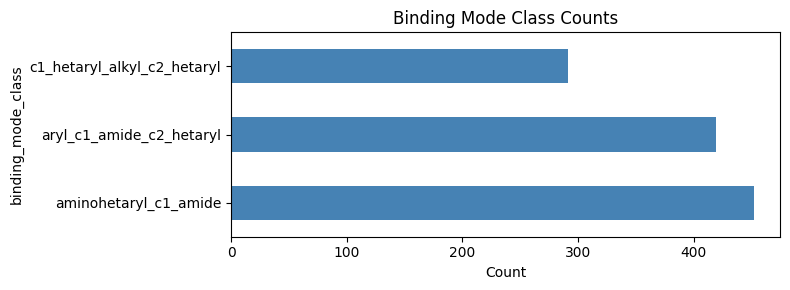

In [32]:
counts = df['binding_mode_class'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 3))
counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Binding Mode Class Counts')
plt.tight_layout()
plt.show()

They are distinct chemical scaffolds and pharmaphoric orientations. Basis for chemotype-based splits

### 1.7 Temporal Coverage

year
2009    241
2010    453
2011    250
2012    141
2013     73
2014      4
Name: count, dtype: int64


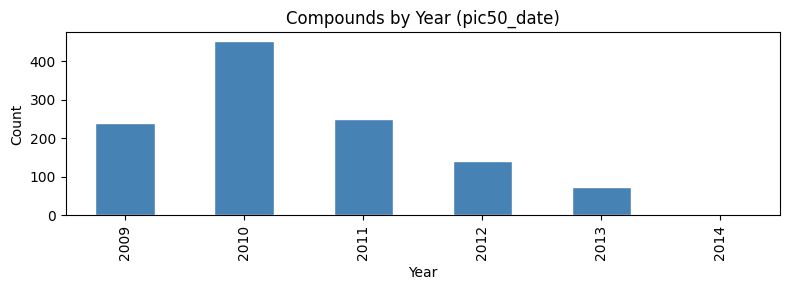

In [33]:
df['year'] = pd.to_datetime(df['pic50_date'], format='%d-%b-%Y').dt.year
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

fig, ax = plt.subplots(figsize=(8, 3))
year_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Compounds by Year (pic50_date)')
plt.tight_layout()
plt.show()


### 1.8 Split Strategy Overview

Each split column assigns rows to `train`, `test`, or `val`. `val` rows and empty rows are excluded from modelling for now see (SYNC-007 synchronizations.md and ADR-003 Decisions.md).

In [34]:
rows_overview = []
for col in SPLIT_COLS:
    vc = df[col].value_counts()
    empty = (df[col] == '').sum() + df[col].isna().sum()
    rows_overview.append({
        'split': col,
        'train': int(vc.get('train', 0)),
        'test': int(vc.get('test', 0)),
        'val': int(vc.get('val', 0)),
        'empty/NaN': int(empty),
    })
split_overview = pd.DataFrame(rows_overview).set_index('split')
display(split_overview)


,train,test,val,empty/NaN
split,,,,
aminohetaryl_c1_amide_split,568,452,141,1
aryl_c1_amide_c2_hetaryl_split,594,419,148,1
temporal_2012_split,848,141,95,78
c1_hetaryl_alkyl_c2_hetaryl_split,696,291,174,1
temporal_2013_split,975,73,109,5
temporal_2011_split,623,250,70,219
random_split,697,233,232,0


### 1.9 Chemical Space

In [35]:
desc = rdkit_descriptors(df[SMILES_COL].tolist())
print(desc.describe().round(2))

ro5_violations = (
    (desc['MW'] > 500).astype(int)
    + (desc['LogP'] > 5).astype(int)
    + (desc['HBD'] > 5).astype(int)
    + (desc['HBA'] > 10).astype(int)
)
print(f'\nLipinski Ro5 — compounds with >=2 violations: {(ro5_violations >= 2).sum()} / {len(desc)}')


            MW     LogP     TPSA      HBD      HBA  RotBonds
count  1162.00  1162.00  1162.00  1162.00  1162.00   1162.00
mean    401.12     2.61   100.05     1.45     7.31      5.42
std      53.05     1.13    27.19     1.09     1.52      1.72
min     255.29    -0.49    30.71     0.00     2.00      1.00
25%     360.39     1.85    79.96     1.00     6.00      4.00
50%     403.45     2.61   101.92     1.00     7.00      5.00
75%     435.22     3.35   118.72     2.00     8.00      7.00
max     717.67     5.82   180.15     5.00    16.00     12.00

Lipinski Ro5 — compounds with >=2 violations: 6 / 1162


MW — mean: 401.1, std: 53.1
     min:  255.3, max: 717.7
     skewness: 0.430
     kurtosis: 2.111


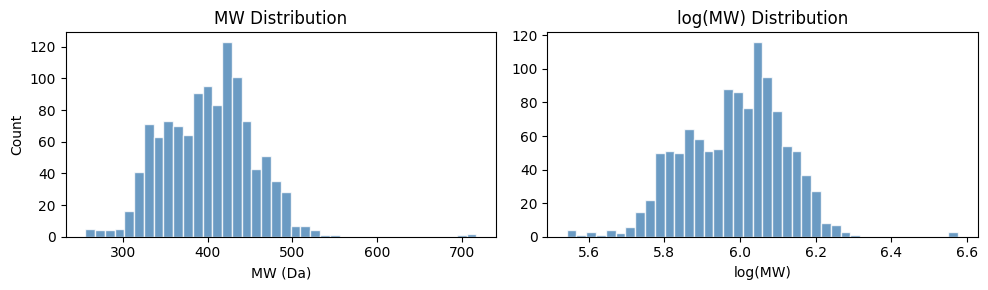

In [36]:
from scipy.stats import skew, kurtosis

mw_vals = desc['MW']
print(f'MW — mean: {mw_vals.mean():.1f}, std: {mw_vals.std():.1f}')
print(f'     min:  {mw_vals.min():.1f}, max: {mw_vals.max():.1f}')
print(f'     skewness: {skew(mw_vals):.3f}')
print(f'     kurtosis: {kurtosis(mw_vals):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(mw_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('MW (Da)')
axes[0].set_ylabel('Count')
axes[0].set_title('MW Distribution')

axes[1].hist(np.log(mw_vals), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log(MW)')
axes[1].set_title('log(MW) Distribution')

plt.tight_layout()
plt.show()

### 1.9a MW vs pIC50 Correlation

Does MW correlate with pIC50? Heavier compounds have more atoms available for binding interactions, so a weak positive correlation is plausible. Pearson r measures linear association; Spearman ρ is robust to non-linearity.

Pearson  r = 0.376  (p=2.637e-40)
Spearman ρ = 0.385  (p=2.254e-42)


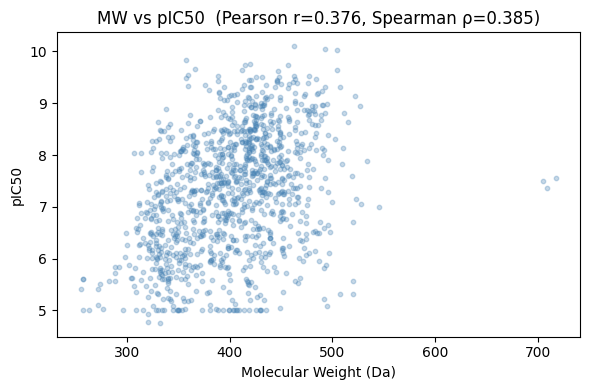

In [37]:
from scipy.stats import pearsonr, spearmanr

mw = desc['MW']
pic50 = df[TARGET_COL]

pearson_r, pearson_p = pearsonr(mw, pic50)
spearman_r, spearman_p = spearmanr(mw, pic50)

print(f'Pearson  r = {pearson_r:.3f}  (p={pearson_p:.3e})')
print(f'Spearman ρ = {spearman_r:.3f}  (p={spearman_p:.3e})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(mw, pic50, alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('Molecular Weight (Da)')
ax.set_ylabel('pIC50')
ax.set_title(f'MW vs pIC50  (Pearson r={pearson_r:.3f}, Spearman ρ={spearman_r:.3f})')
plt.tight_layout()
plt.show()

### 1.10 EDA Conclusions

- **1162 compounds**, single target (`pic50`), no missing values
- SMILES validity and duplicate counts as printed above
- `pic50` distribution: unimodal, centred ~7–9 (potent PDE10A inhibitors)
- 3 binding mode classes; `aminohetaryl_c1_amide` is the largest group (452 test compounds in its chemotype split), followed by `aryl_c1_amide_c2_hetaryl` (419) and `c1_hetaryl_alkyl_c2_hetaryl` (291)
- Temporal range: 2010–2013; temporal splits reflect this chronology
- `random_split`: most complete (0 empty rows); `temporal_2011_split`: 219 empty rows
- Most compounds satisfy Lipinski Ro5
- 3σ outlier tag added to `df['outlier_pic50']` — see section 1.5

---

## Part 2 — Featurization & Baseline Models

Same 5 models as ADME Phase 1: Ridge, BayesianRidge, RandomForest, XGBoost, LightGBM.  
Morgan fingerprints (ECFP4, radius=2, 2048 bits) computed **once** for all 1162 compounds and indexed per split.  
Metrics: R² and RMSE on the `test` partition of each of the 7 split strategies.

### 2.1 Featurize All Compounds (ECFP4)

In [38]:
print('Computing ECFP4 fingerprints for all 1162 compounds...')
X_all = morgan_fingerprints(df[SMILES_COL].tolist())
y_all = df[TARGET_COL].values
print(f'X_all shape: {X_all.shape}')
print(f'y_all shape: {y_all.shape}')


Computing ECFP4 fingerprints for all 1162 compounds...
X_all shape: (1162, 2048)
y_all shape: (1162,)


### 2.2 Build Train/Test Splits

In [39]:
split_data = {}
for split_col in list_split_cols(df):
    train_df, test_df = get_split(df, split_col)
    # df has a clean RangeIndex, so .index values equal positional indices into X_all/y_all
    train_idx = train_df.index.to_numpy()
    test_idx = test_df.index.to_numpy()
    split_data[split_col] = (
        X_all[train_idx],
        X_all[test_idx],
        y_all[train_idx],
        y_all[test_idx],
    )
    print(f'{split_col}: train={len(train_df)}, test={len(test_df)}')

aminohetaryl_c1_amide_split: train=568, test=452
aryl_c1_amide_c2_hetaryl_split: train=594, test=419
temporal_2012_split: train=848, test=141
c1_hetaryl_alkyl_c2_hetaryl_split: train=696, test=291
temporal_2013_split: train=975, test=73
temporal_2011_split: train=623, test=250
random_split: train=697, test=233


### 2.3 Model Training & Evaluation

In [40]:
rows_results = []
preds_store = {}

for split_col, (X_train, X_test, y_train, y_test) in split_data.items():
    preds_store[split_col] = {}
    for name, model in get_baseline_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        preds_store[split_col][name] = (y_test, y_pred)
        metrics = evaluate_model(model, X_test, y_test, y_pred=y_pred)
        rows_results.append({'split': split_col, 'model': name, **metrics})

results_df = pd.DataFrame(rows_results)
print(f'Results: {results_df.shape[0]} rows (expected 35 = 7 splits x 5 models)')
results_df.head(10)

Results: 42 rows (expected 35 = 7 splits x 5 models)


,split,model,R2,RMSE,MSE
0,aminohetaryl_c1_amide_split,MeanPredictor,-0.115917,1.197300,1.433527
1,aminohetaryl_c1_amide_split,Ridge,-0.624696,1.444684,2.087112
2,aminohetaryl_c1_amide_split,BayesianRidge,-0.880261,1.554161,2.415417
3,aminohetaryl_c1_amide_split,RandomForest,-0.457363,1.368267,1.872154
4,aminohetaryl_c1_amide_split,XGBoost,-0.824434,1.530915,2.343700
5,aminohetaryl_c1_amide_split,LightGBM,-0.231245,1.257648,1.581679
6,aryl_c1_amide_c2_hetaryl_split,MeanPredictor,-0.103665,1.236326,1.528503
7,aryl_c1_amide_c2_hetaryl_split,Ridge,-0.582593,1.480468,2.191787
8,aryl_c1_amide_c2_hetaryl_split,BayesianRidge,-0.418607,1.401669,1.964677
9,aryl_c1_amide_c2_hetaryl_split,RandomForest,-0.269925,1.326183,1.758762


### 2.4 Results Summary

In [41]:
r2_pivot = results_df.pivot(index='split', columns='model', values='R2').round(3)
rmse_pivot = results_df.pivot(index='split', columns='model', values='RMSE').round(3)

print('R\u00b2 by split and model:')
display(r2_pivot)
print('\nRMSE by split and model:')
display(rmse_pivot)


R² by split and model:


model,BayesianRidge,LightGBM,MeanPredictor,RandomForest,Ridge,XGBoost
split,,,,,,
aminohetaryl_c1_amide_split,-0.880,-0.231,-0.116,-0.457,-0.625,-0.824
aryl_c1_amide_c2_hetaryl_split,-0.419,-0.231,-0.104,-0.270,-0.583,-0.364
c1_hetaryl_alkyl_c2_hetaryl_split,-3.598,-1.900,-0.008,-1.103,-4.336,-1.316
random_split,0.587,0.542,-0.005,0.519,0.489,0.583
temporal_2011_split,-0.489,-0.248,-0.010,-0.307,-0.777,-0.692
temporal_2012_split,-2.322,-1.753,-0.047,-1.090,-3.035,-1.431
temporal_2013_split,0.572,0.323,-0.064,0.285,0.401,0.247



RMSE by split and model:


model,BayesianRidge,LightGBM,MeanPredictor,RandomForest,Ridge,XGBoost
split,,,,,,
aminohetaryl_c1_amide_split,1.554,1.258,1.197,1.368,1.445,1.531
aryl_c1_amide_c2_hetaryl_split,1.402,1.306,1.236,1.326,1.480,1.375
c1_hetaryl_alkyl_c2_hetaryl_split,2.444,1.941,1.144,1.652,2.632,1.734
random_split,0.761,0.802,1.188,0.821,0.846,0.765
temporal_2011_split,1.245,1.140,1.026,1.166,1.360,1.327
temporal_2012_split,2.115,1.925,1.187,1.677,2.331,1.809
temporal_2013_split,0.775,0.975,1.222,1.002,0.917,1.028


Key takeaways:

- BayesianRidge performs the best on easy splits (random and temporal_2013 - largest temporal dataset split)
- LightGMB performs best on the tougher splits
- Ridge is mediocore but better than linear regression (removed as was soo poorly performing)
- All models struggle on chemotype splits with a negative R2

### 2.5 Cross-Split Comparison

R² per model across all 7 split strategies. Question: does the choice of split inflate or deflate reported R²? Random splits typically give the most optimistic R²; temporal and chemotype splits are harder tests of generalisation.

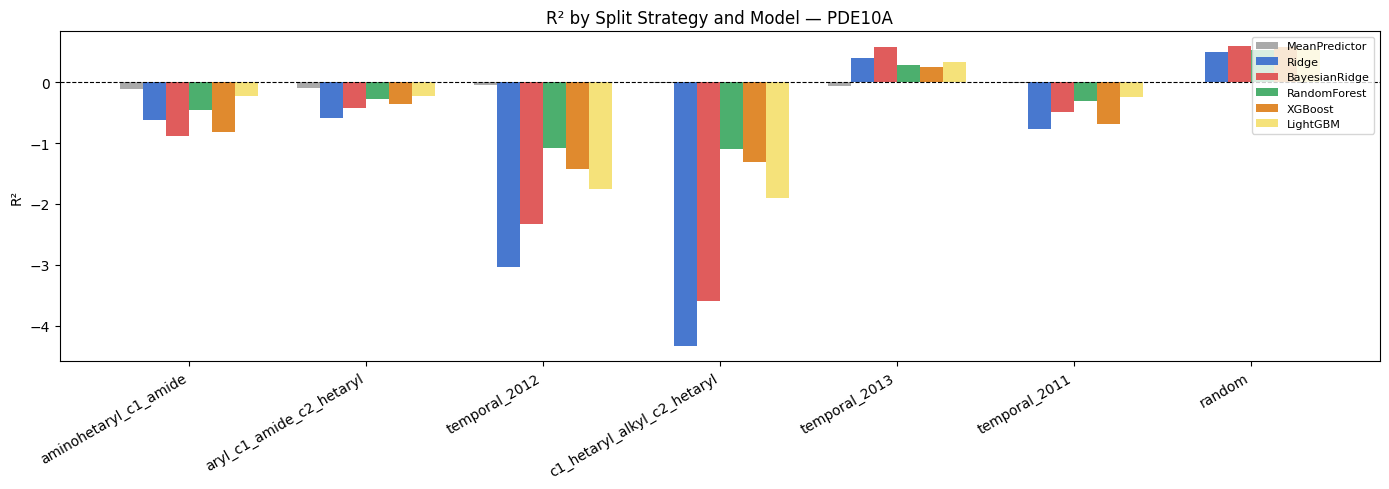

In [42]:
model_names = ['MeanPredictor', 'Ridge', 'BayesianRidge', 'RandomForest', 'XGBoost', 'LightGBM']
model_colors = {
    'MeanPredictor': '#aaaaaa',
    'Ridge':         '#4878cf',
    'BayesianRidge': '#e05c5c',
    'RandomForest':  '#4caf6e',
    'XGBoost':       '#e08a2e',
    'LightGBM':      '#f5e27a',
}
split_keys = list(split_data.keys())
split_labels = [s.replace('_split', '') for s in split_keys]

x = np.arange(len(split_labels))
width = 0.13

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(model_names):
    r2_vals = [
        results_df[(results_df['split'] == s) & (results_df['model'] == model)]['R2'].values[0]
        for s in split_keys
    ]
    ax.bar(x + i * width, r2_vals, width, label=model, color=model_colors[model])

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(split_labels, rotation=30, ha='right')
ax.set_ylabel('R²')
ax.set_title('R² by Split Strategy and Model — PDE10A')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 2.6 Predicted vs Actual — all 7 split strategies

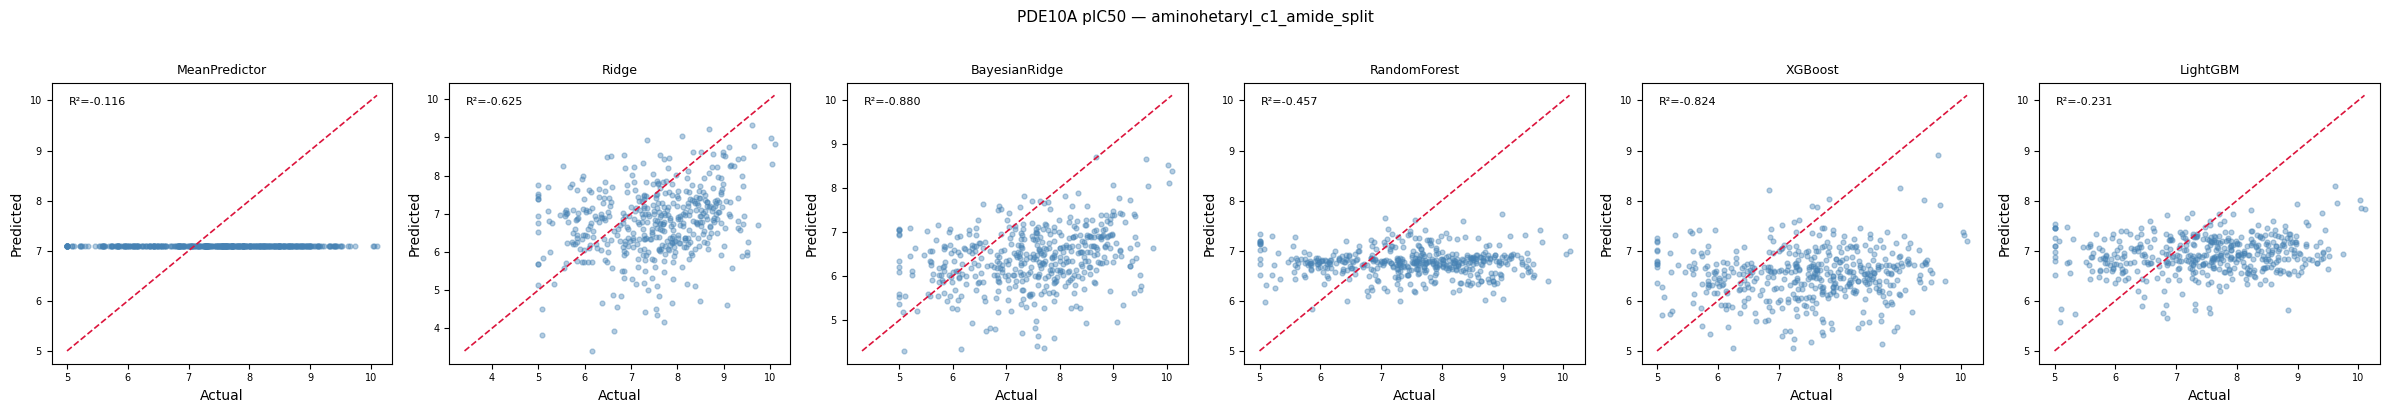

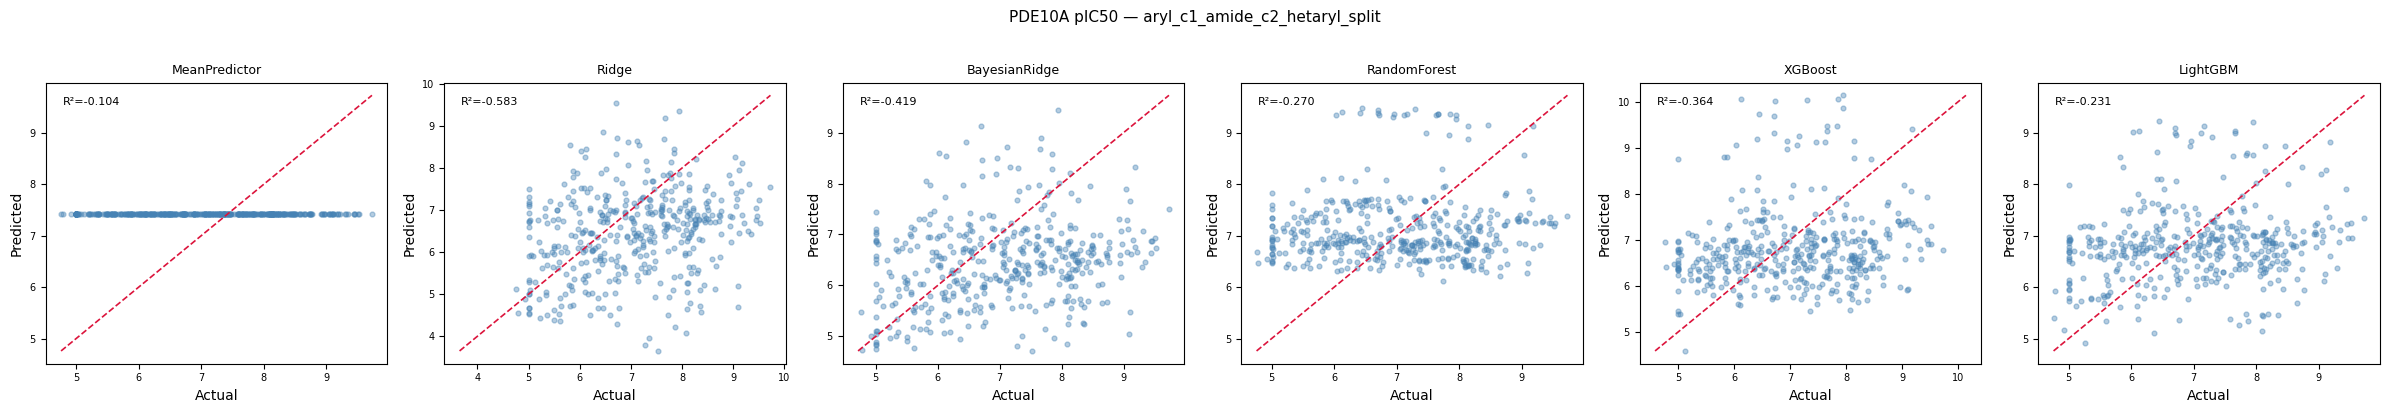

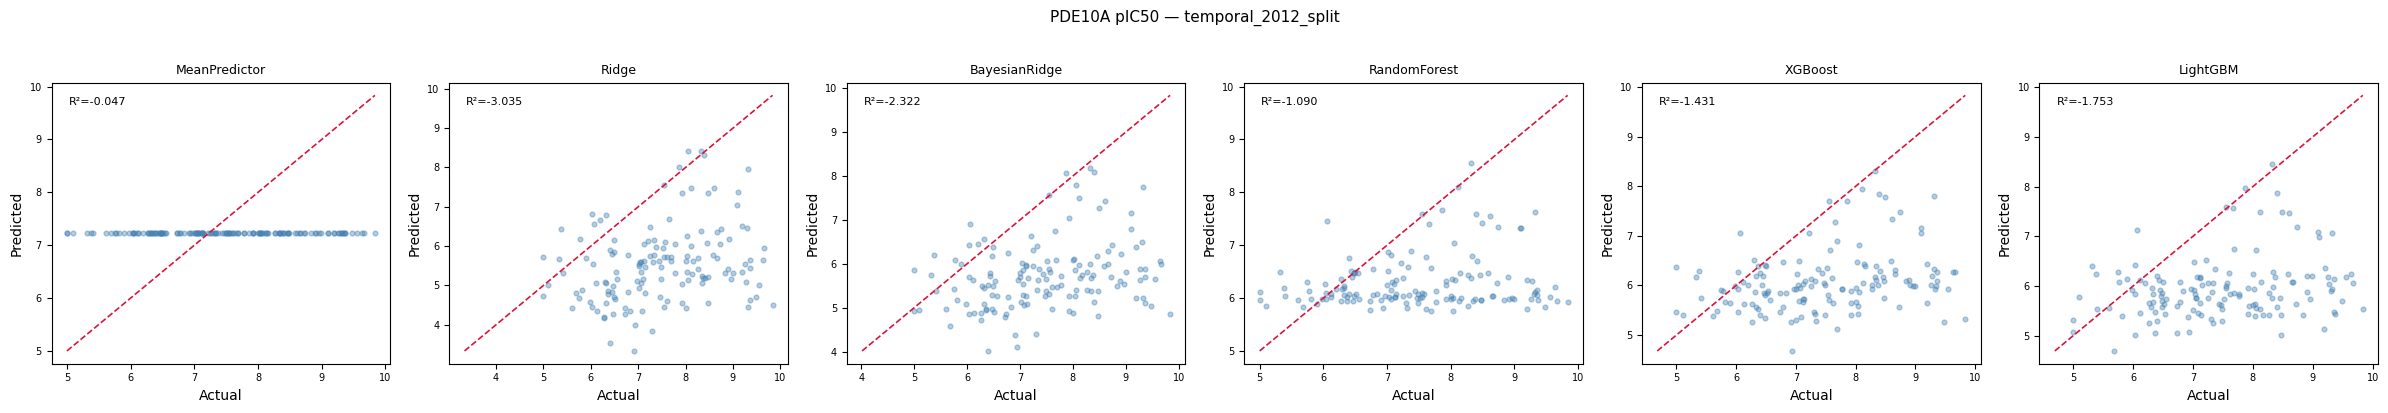

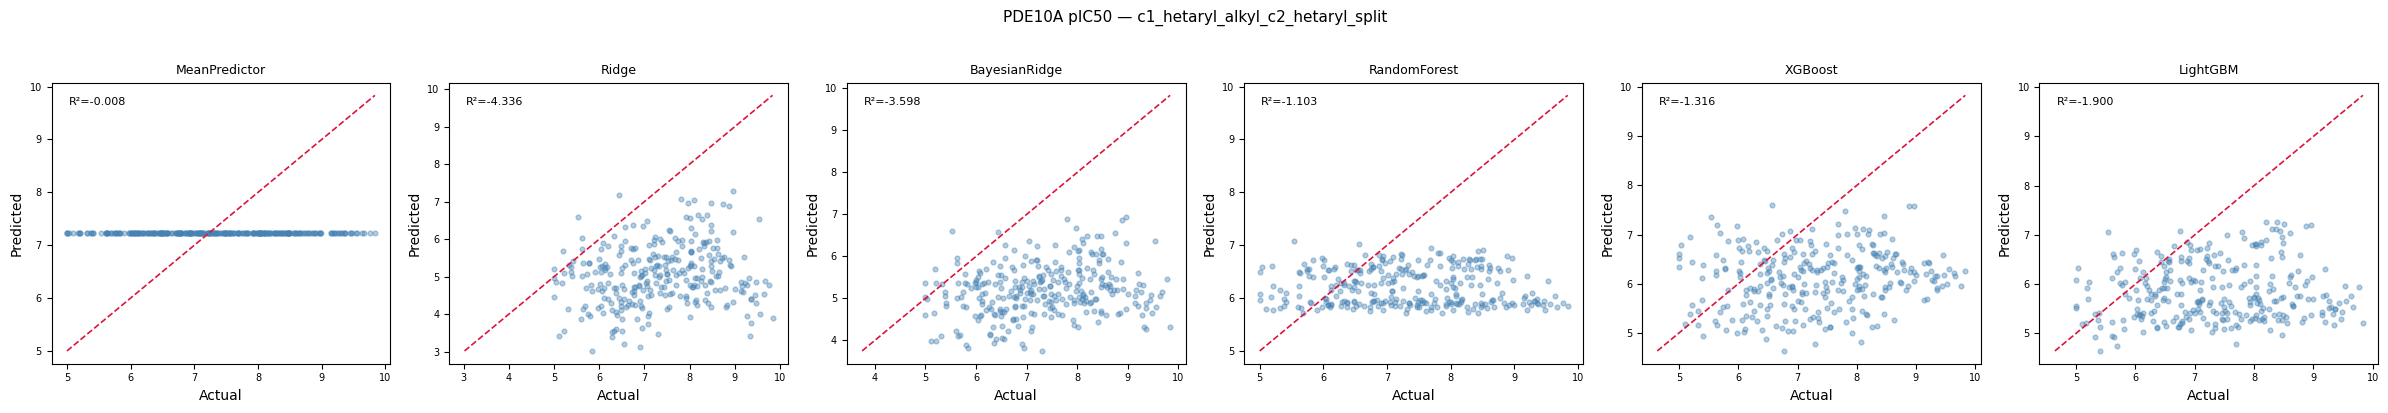

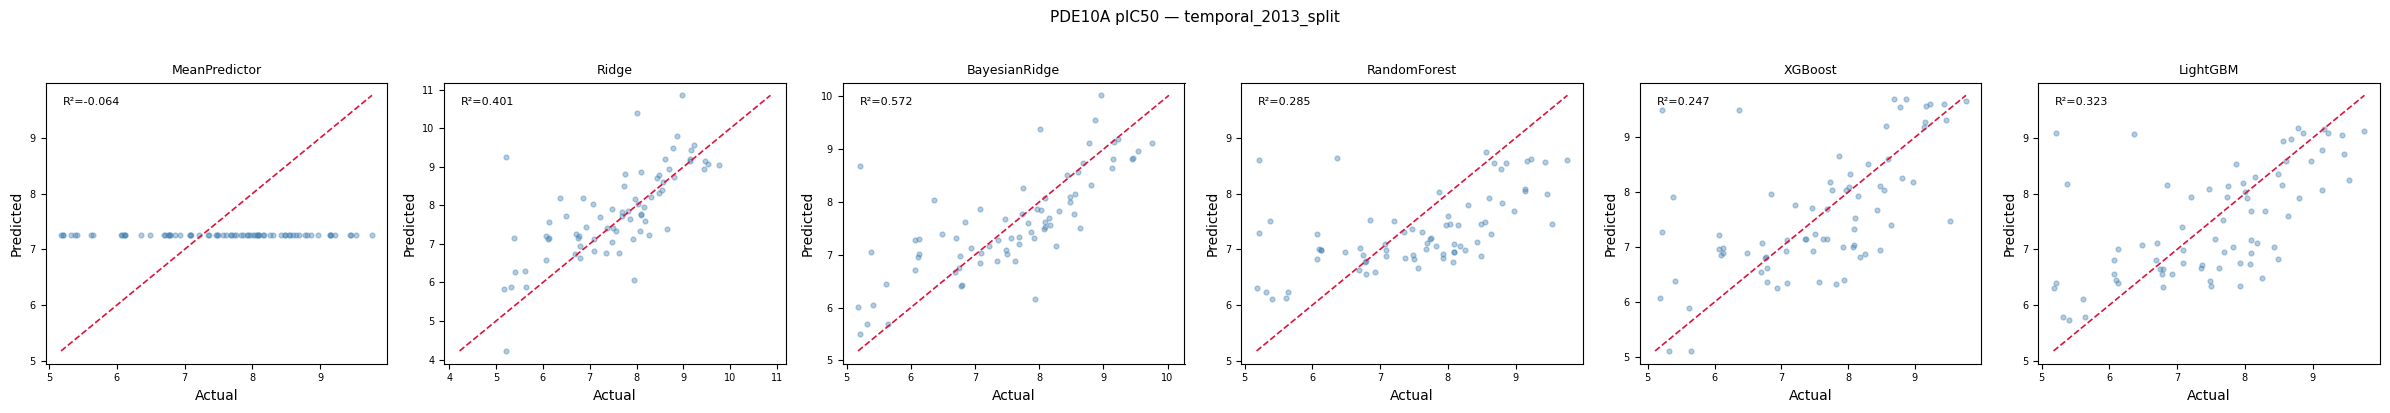

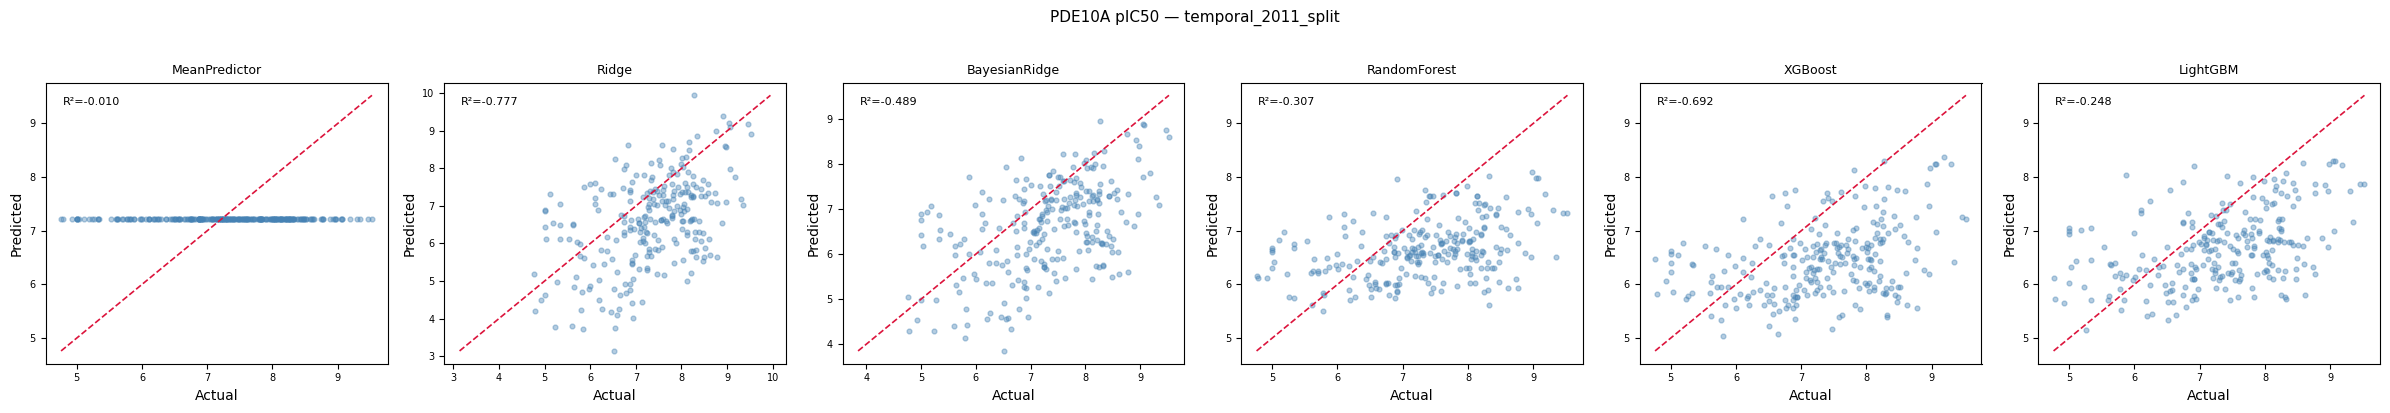

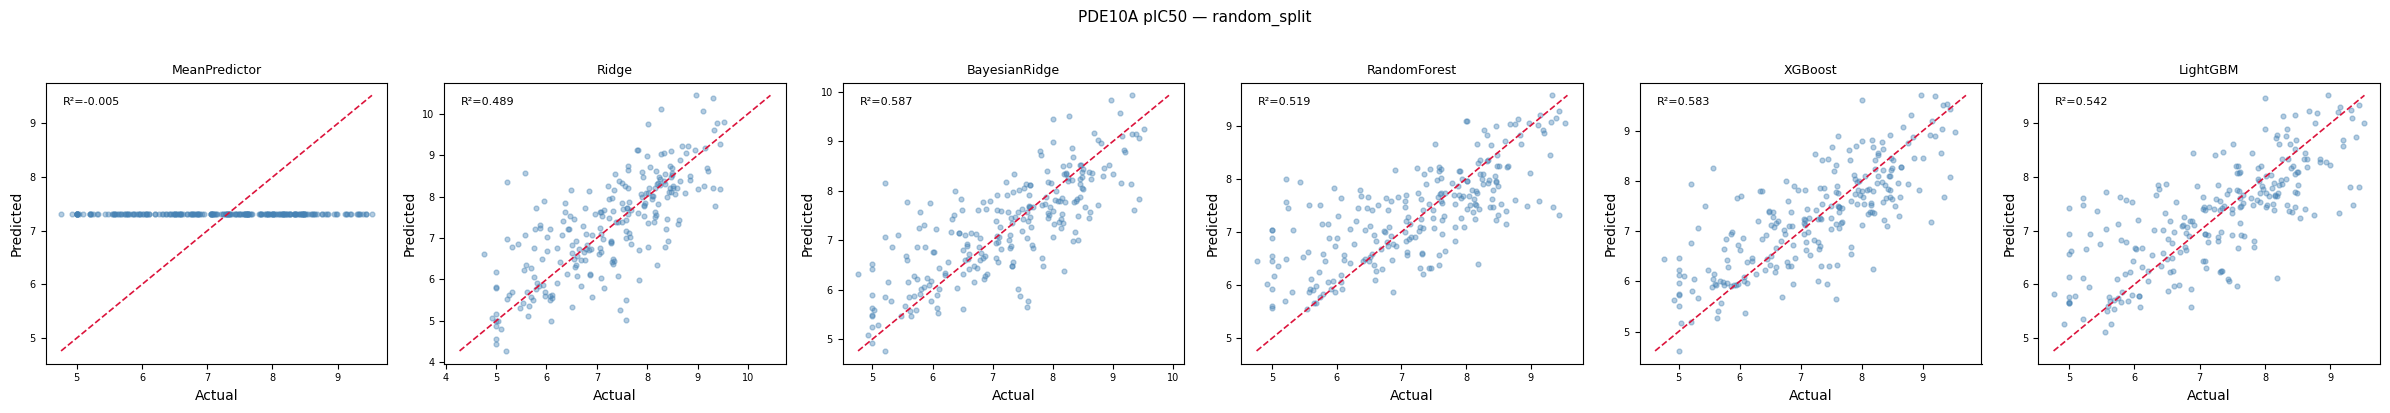

In [43]:
for split_col, preds in preds_store.items():
    fig = pred_vs_actual_grid(
        preds,
        title=f"PDE10A pIC50 — {split_col}"
    )
    plt.show()


### 2.7 Dummy Baseline Interpretation

**MeanPredictor** always predicts the training set mean pIC50, ignoring molecular structure entirely. Its R² is approximately 0 when the test distribution matches training, and negative when it shifts (the training mean becomes a bad guess for a shifted test set).

**Results against the dummy:**

| Split | MeanPredictor R² | Beat by real models? |
|---|---|---|
| `random_split` | −0.005 | ✅ all 5 models beat it |
| `temporal_2013_split` | −0.064 | ✅ all 5 models beat it |
| `aminohetaryl_c1_amide_split` | −0.116 | ❌ all 5 models worse (best: LightGBM −0.231) |
| `aryl_c1_amide_c2_hetaryl_split` | −0.104 | ❌ all 5 models worse (best: LightGBM −0.231) |
| `c1_hetaryl_alkyl_c2_hetaryl_split` | −0.008 | ❌ all 5 models worse (best: RandomForest −1.103) |
| `temporal_2011_split` | −0.010 | ❌ all 5 models worse (best: LightGBM −0.248) |
| `temporal_2012_split` | −0.047 | ❌ all 5 models worse (best: RandomForest −1.090) |

On 5 of 7 splits, **every model performs worse than simply predicting the training mean** — the fingerprints are providing no useful signal. Only on `random_split` and `temporal_2013_split` (where train and test are drawn from similar distributions) do the models demonstrate any learning.

### 2.8 Single-Descriptor Baseline: Ridge(MW-only)

Train Ridge regression using only molecular weight as a single feature across all 7 splits. Compared against MeanPredictor (structure-blind) and Ridge(ECFP4) (2048-bit fingerprints).

- If Ridge(MW) > MeanPredictor: MW alone carries learnable pIC50 signal
- If Ridge(MW) ≈ MeanPredictor: the global MW-pIC50 correlation seen in 1.9a doesn't survive the train/test boundary — MW is not predictive split-by-split
- The gap between Ridge(MW) and Ridge(ECFP4) shows how much structural information the fingerprints add beyond a single descriptor

In [44]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

X_mw = desc['MW'].values.reshape(-1, 1)

mw_rows = []
for split_col in list_split_cols(df):
    train_df, test_df = get_split(df, split_col)
    train_idx = train_df.index.to_numpy()
    test_idx  = test_df.index.to_numpy()
    X_train_mw, X_test_mw = X_mw[train_idx], X_mw[test_idx]
    _, _, y_train, y_test = split_data[split_col]

    scaler = StandardScaler()
    X_train_mw = scaler.fit_transform(X_train_mw)  # fit on train only
    X_test_mw  = scaler.transform(X_test_mw)        # apply same scale to test

    model = Ridge(alpha=1.0)
    model.fit(X_train_mw, y_train)
    metrics = evaluate_model(model, X_test_mw, y_test)
    mw_rows.append({'split': split_col, 'model': 'Ridge(MW)', **metrics})

mw_df = pd.DataFrame(mw_rows)
print(f'MW-only results: {mw_df.shape[0]} rows (expected 7)')
mw_df[['split', 'R2', 'RMSE']].round(3)

MW-only results: 7 rows (expected 7)


,split,R2,RMSE
0,aminohetaryl_c1_amide_split,0.156,1.042
1,aryl_c1_amide_c2_hetaryl_split,0.096,1.119
2,temporal_2012_split,-0.209,1.276
3,c1_hetaryl_alkyl_c2_hetaryl_split,-0.212,1.254
4,temporal_2013_split,-0.258,1.329
5,temporal_2011_split,0.110,0.962
6,random_split,0.118,1.112


In [45]:
compare = pd.concat([
    results_df[results_df['model'].isin(['MeanPredictor', 'Ridge'])],
    mw_df
])

r2_compare = compare.pivot(index='split', columns='model', values='R2')[
    ['MeanPredictor', 'Ridge(MW)', 'Ridge']
].round(3)
rmse_compare = compare.pivot(index='split', columns='model', values='RMSE')[
    ['MeanPredictor', 'Ridge(MW)', 'Ridge']
].round(3)

print('R² — MeanPredictor vs Ridge(MW-only) vs Ridge(ECFP4):')
display(r2_compare)
print('\nRMSE — MeanPredictor vs Ridge(MW-only) vs Ridge(ECFP4):')
display(rmse_compare)

R² — MeanPredictor vs Ridge(MW-only) vs Ridge(ECFP4):


model,MeanPredictor,Ridge(MW),Ridge
split,,,
aminohetaryl_c1_amide_split,-0.116,0.156,-0.625
aryl_c1_amide_c2_hetaryl_split,-0.104,0.096,-0.583
c1_hetaryl_alkyl_c2_hetaryl_split,-0.008,-0.212,-4.336
random_split,-0.005,0.118,0.489
temporal_2011_split,-0.010,0.110,-0.777
temporal_2012_split,-0.047,-0.209,-3.035
temporal_2013_split,-0.064,-0.258,0.401



RMSE — MeanPredictor vs Ridge(MW-only) vs Ridge(ECFP4):


model,MeanPredictor,Ridge(MW),Ridge
split,,,
aminohetaryl_c1_amide_split,1.197,1.042,1.445
aryl_c1_amide_c2_hetaryl_split,1.236,1.119,1.480
c1_hetaryl_alkyl_c2_hetaryl_split,1.144,1.254,2.632
random_split,1.188,1.112,0.846
temporal_2011_split,1.026,0.962,1.360
temporal_2012_split,1.187,1.276,2.331
temporal_2013_split,1.222,1.329,0.917


**2.8 Takeaways**

Ridge(MW) beats Ridge(ECFP4) on 5/7 splits — a single continuous property outperforms 2048-bit structural fingerprints on most splits.

ECFP4 is encoding exactly what it should: local structural fragments. The problem is that those fragments are chemotype-specific. When the test set belongs to a different chemotype or a later time window, most of the fingerprint bits the model learned weights for are either absent or novel in the test compounds — the structural vocabulary doesn't transfer.

MW, being a continuous global property, transfers across any scaffold. That's why it generalises better when distributions shift.

**What this means:**
- On `random_split` and `temporal_2013` (similar train/test distributions), ECFP4 wins — the model can learn scaffold-potency relationships that hold in test
- On chemotype and most temporal splits, ECFP4 is encoding the wrong thing — not "how potent is this compound" but "which chemotype does this compound belong to"
- The failure is a **distribution shift problem**, not a featurisation quality problem; better-regularised models (LightGBM, RF) suffer less because they're less sensitive to irrelevant bits, but they can't overcome a fundamentally different test distribution

Would adding MW as an additional feature alongside ECFP4 help?

chceck paper on the 2d models they used well, why they might have performed better comapred to morgan,
how much is molecular weight predictive on potency, if had single descriptor as part of input features
could normalise on molecular weight to see how it performs
put results in context of what paper did

Look to improve the models, so can say these are the main models want to add/remove noise for, temporal split only one that works best
